#06 -- Holt's Linear Trend Method 

In thi netobook, We apply **Holt's Linear Trend Method** to the monthly total passenger series for jfk airport.

## Objective 
The aim is to improve upon Simple Exponential Smoothing by incorparating a trend component into the forecasting model. 

## Why Holt’s Linear Trend?

Simple Exponential Smoothing only models the level of a time series.

However, the JFK passenger series shows a visible upward trend over time.  
For this reason, Holt’s Linear Trend method is more appropriate because it models:

- the level,
- and the trend.

This allows the model to produce forecasts that change over time instead of remaining flat.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import Holt, SimpleExpSmoothing


## Importing Libraries

We import the required libraries for data handling, visualization, and Holt’s trend-based forecasting model.

In [23]:
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

df_jfk = df[df['Airport Code'] == 'JFK'].copy()

df_jfk['Date'] = pd.to_datetime(
    df_jfk['Year'].astype(str) + '-' + df_jfk['Month'].astype(str) + '-01'
)

ts = df_jfk.groupby('Date')['Total Passengers'].sum().sort_index()

ts.head(10)

Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
1977-06-01    1906396
1977-07-01    2373334
1977-08-01    2372987
1977-09-01    2010979
1977-10-01    1806198
Name: Total Passengers, dtype: int64

## Preparing the Time Series

I load tha dataset, filter the observations for JFK airport,create a proper datetime column, and build the monthly total passenger time series. 


## Time Series Visualization

Before applying Holt’s method, we visualize the time series again to examine its structure.

This helps us confirm whether a trend component exists and whether Holt’s method is appropriate.

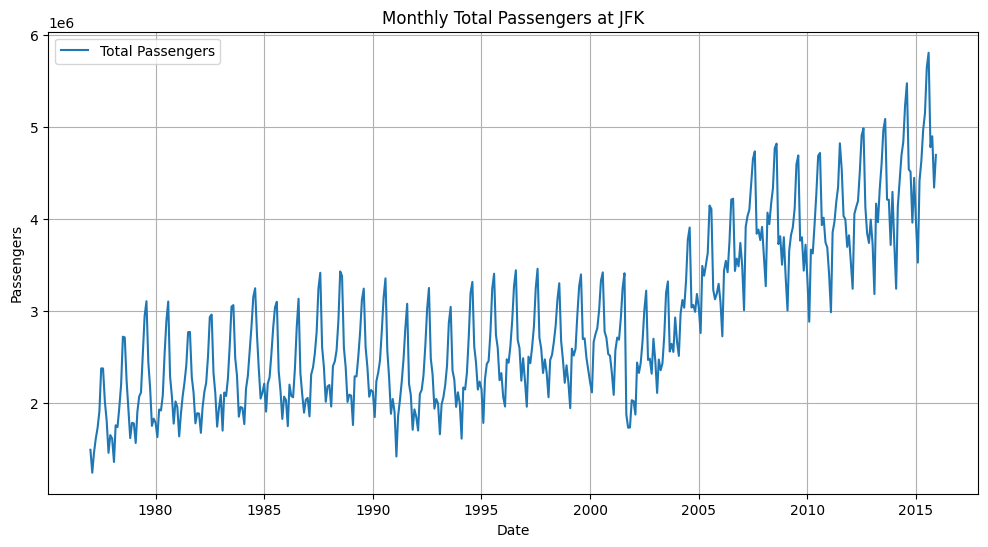

In [24]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Total Passengers')

plt.title('Monthly Total Passengers at JFK')
plt.xlabel('Date')
plt.ylabel('Passengers')

plt.legend()
plt.grid(True)
plt.show()

## Suitability of Holt’s Method

From the plot, we clearly observe:

- a strong upward trend over time,
- noticeable fluctuations in the series.

Unlike Simple Exponential Smoothing, Holt’s method is capable of modeling this trend.

Therefore, Holt’s Linear Trend method is more appropriate for this dataset, as it can produce forecasts that follow the increasing pattern of the data.

## Applying Holt's Linear Trend Model

we apply Holt's L.T.M to the time series. 

This model extend Simple Exponential Smoothing by adding a trend component, 
allowing it to capture upward or downward movements in the data.

In [25]:
model = Holt(ts)
model_fit = model.fit()


c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Model Fitting

The model is fitted to the data.

By default, the smoothing parameters are automatically optimized to best match the trend and level of the series.

In [26]:
fitted_values = model_fit.fittedvalues

In [27]:
forecast = model_fit.forecast(12)

## Forecasting 

we generate forecasts for the next 12 months. 

unlike SES, Holt's method allows the forecast to follow a trend rather than remaining flat.

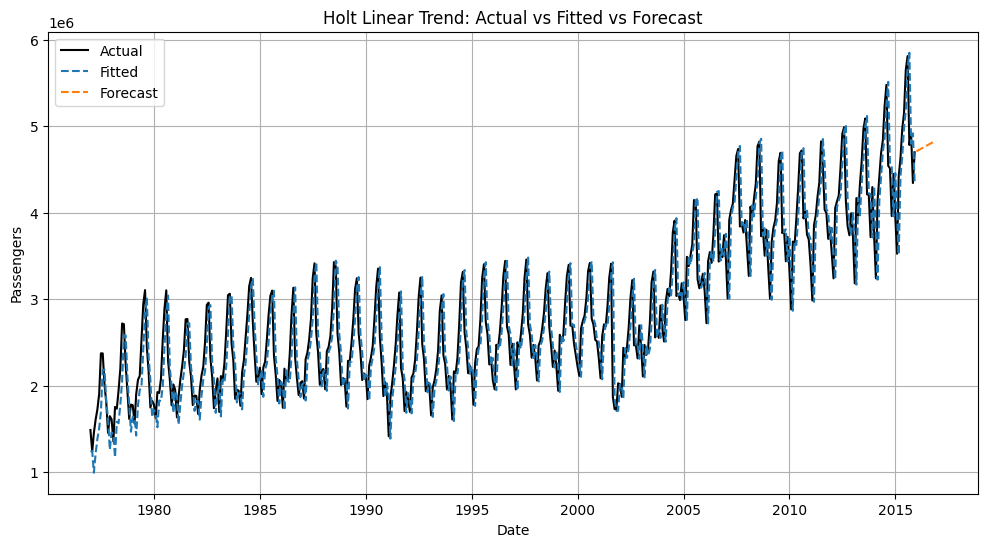

In [28]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')
plt.plot(fitted_values, label='Fitted', linestyle='--')
plt.plot(forecast, label='Forecast', linestyle='--')

plt.title('Holt Linear Trend: Actual vs Fitted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)

plt.show()

## Interpretation

The Holt model performs significantly better than Simple Exponential Smoothing:

- It successfully captures the upward trend in the data.
- The fitted values follow the overall direction of the series more closely.
- The forecast continues the increasing pattern instead of remaining flat.

However, the model still does not capture seasonal fluctuations.

This suggests that while Holt improves upon SES, a model that also includes seasonality (such as Holt-Winters) would provide even better results.

## Effect of Smoothing Parameters (Alpha & Beta)

Holt’s method introduces two smoothing parameters:

- **Alpha (level):** controls how quickly the level adapts
- **Beta (trend):** controls how quickly the trend adapts

We will test different combinations to observe how they affect the model behavior.

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


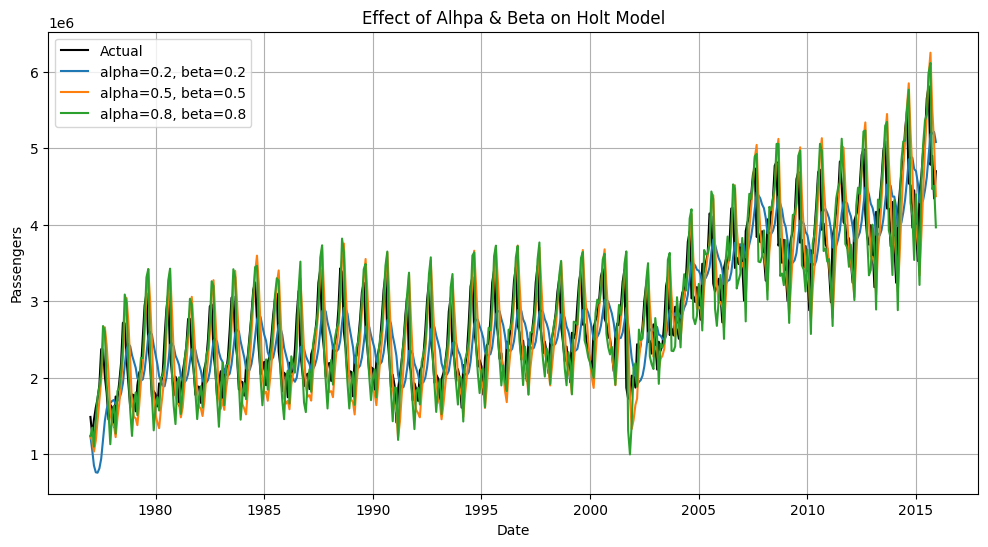

In [29]:
params = [
    (0.2, 0.2),
    (0.5, 0.5),
    (0.8, 0.8)
]

plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')

for alpha, beta in params:
    model = Holt(ts)
    model_fit = model.fit(
        smoothing_level=alpha,
        smoothing_trend=beta,
        optimized=False
    )

    fitted = model_fit.fittedvalues
    plt.plot(fitted, label=f'alpha={alpha}, beta={beta}')

plt.title('Effect of Alhpa & Beta on Holt Model')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Alpha & Beta Effects

The combination of alpha and beta significantly affects how the model behaves:

- **Low values (0.2, 0.2):**
  The model is smoother and more stable but reacts slowly to changes, causing lag.

- **Medium values (0.5, 0.5):**
  The model achieves a balance between responsiveness and smoothness, capturing the overall trend effectively.

- **High values (0.8, 0.8):**
  The model reacts quickly to both level and trend changes, closely following the data but also capturing noise, which may reduce stability.

This demonstrates that both level and trend components must be carefully tuned to balance stability and responsiveness.

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


NameError: name 'ply' is not defined

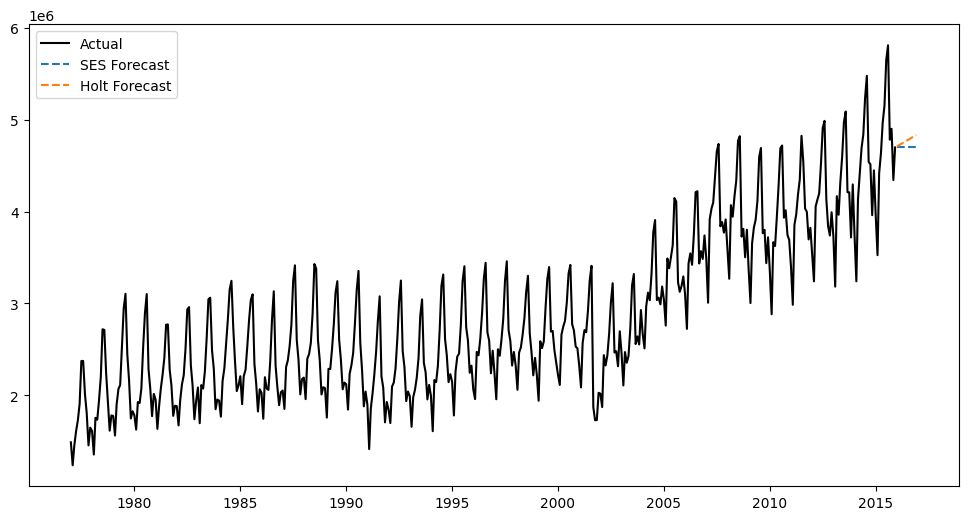

In [32]:
# SES model 
ses_model = SimpleExpSmoothing(ts).fit()
ses_forecast = ses_model.forecast(12)

# Holt model
holt_model = Holt(ts).fit()
holt_forecast = holt_model.forecast(12)

# Plot 
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')
plt.plot(ses_forecast, label='SES Forecast', linestyle='--')
plt.plot(holt_forecast, label='Holt Forecast', linestyle='--')
plt.legend()
ply.grid(True)
plt.show()

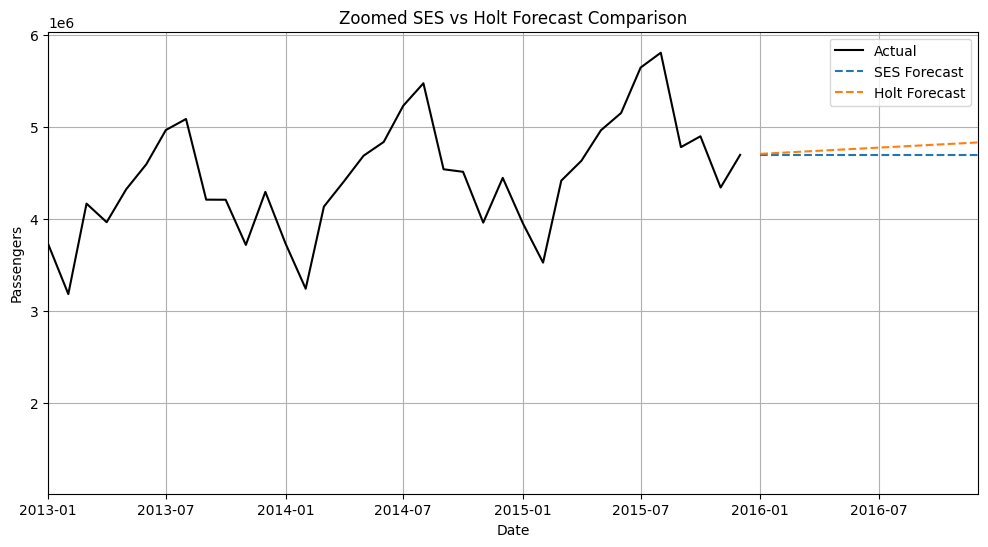

In [33]:
plt.figure(figsize=(12,6))

plt.plot(ts, label='Actual', color='black')
plt.plot(ses_forecast, label='SES Forecast', linestyle='--')
plt.plot(holt_forecast, label='Holt Forecast', linestyle='--')

plt.title('Zoomed SES vs Holt Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)

plt.xlim(ts.index[-36], holt_forecast.index[-1])

plt.show()

## Residual Analysis

To better evaluate model performance, we analyze the residuals (errors).

Residual = Actual - Fitted

Smaller and more stable residuals indicate a better model fit.

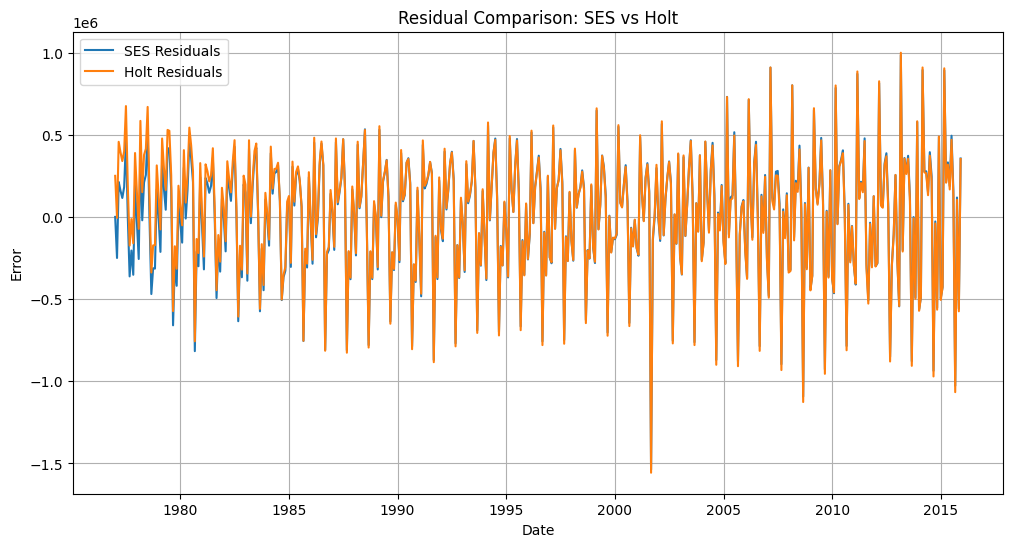

In [35]:
# Residuals

ses_residuals = ts - ses_model.fittedvalues
holt_residuals = ts - holt_model.fittedvalues

plt.figure(figsize=(12,6))

plt.plot(ses_residuals, label='SES Residuals')
plt.plot(holt_residuals, label='Holt Residuals')

plt.title('Residual Comparison: SES vs Holt')
plt.xlabel('Date')
plt.ylabel('Error')

plt.legend()
plt.grid(True)

plt.show()


C:\Users\Merve\AppData\Local\Temp\ipykernel_10684\1628862821.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ses_residuals.dropna(), holt_residuals.dropna()],


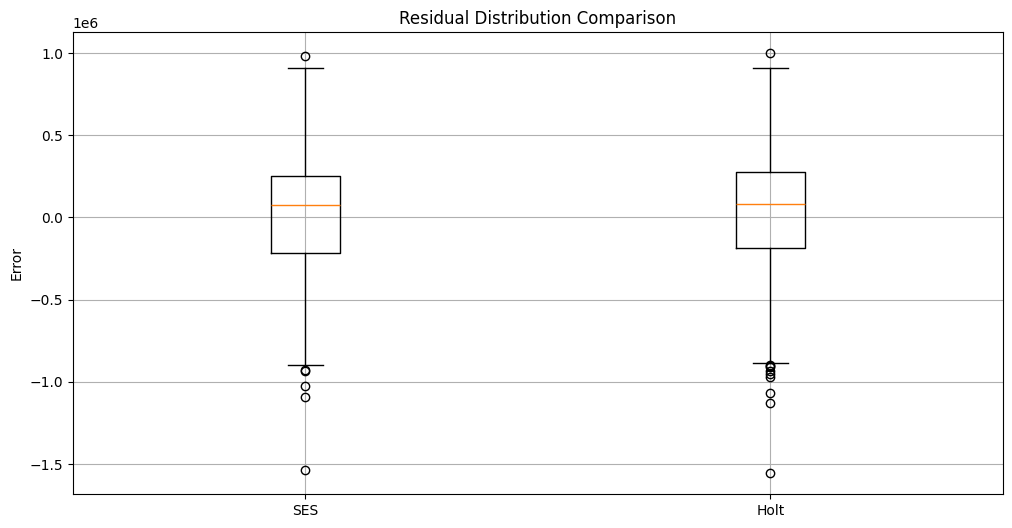

In [37]:
plt.figure(figsize=(12,6))
plt.boxplot([ses_residuals.dropna(), holt_residuals.dropna()],
            labels=['SES', 'Holt'])

plt.title('Residual Distribution Comparison')
plt.ylabel('Error')

plt.grid(True)
plt.show()

## Final Model Evaluation

The comparison between SES and Holt reveals several key insights:

- Holt successfully captures the trend in the data, while SES fails to do so.
- However, both models exhibit structured residual patterns, indicating that important information is still not captured.
- The residual distributions are similar, suggesting that modeling trend alone is not sufficient.

This strongly suggests that the main missing component is **seasonality**.

Therefore, a model that incorporates:
- level,
- trend,
- and seasonality

(such as Holt-Winters) is expected to provide significantly better performance.